In [99]:
!pip -q install gradio

In [100]:
# Importing Libraries
import pandas as pd
import seaborn as s
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import gradio as gr

df=pd.read_csv("salary_data.csv")
df.head()

,Age,Experience,Education,Job_Role,City,Salary
0,42,15,Bachelor,Data Scientist,Noida,1916541
1,38,17,Bachelor,Data Scientist,Chennai,2196338
2,24,3,Bachelor,AI Engineer,Delhi,1219746
3,41,11,Bachelor,Business Analyst,Delhi,1305808
4,29,8,Master,AI Engineer,Indore,1793937


In [101]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Age         1000 non-null   int64 
 1   Experience  1000 non-null   int64 
 2   Education   1000 non-null   object
 3   Job_Role    1000 non-null   object
 4   City        1000 non-null   object
 5   Salary      1000 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 47.0+ KB


In [102]:
df.isnull().sum()

,0
Age,0
Experience,0
Education,0
Job_Role,0
City,0
Salary,0


In [103]:
df.describe()

,Age,Experience,Salary
count,1000.000000,1000.000000,1.000000e+03
mean,33.495000,7.558000,1.404002e+06
std,6.828807,5.371358,5.628025e+05
min,22.000000,0.000000,2.500000e+05
25%,28.000000,3.000000,9.531775e+05
50%,34.000000,7.000000,1.362396e+06
75%,39.000000,12.000000,1.767518e+06
max,45.000000,20.000000,3.179172e+06


In [104]:
display(df[df['Salary']==df["Salary"].max()])
df['Est_Starting_Age'] = df['Age'] - df['Experience']

,Age,Experience,Education,Job_Role,City,Salary
227,42,20,PhD,AI Architect,Bangalore,3179172


In [105]:
display(df)

,Age,Experience,Education,Job_Role,City,Salary,Est_Starting_Age
0,42,15,Bachelor,Data Scientist,Noida,1916541,27
1,38,17,Bachelor,Data Scientist,Chennai,2196338,21
2,24,3,Bachelor,AI Engineer,Delhi,1219746,21
3,41,11,Bachelor,Business Analyst,Delhi,1305808,30
4,29,8,Master,AI Engineer,Indore,1793937,21
...,...,...,...,...,...,...,...
995,25,0,Master,AI Architect,Indore,1194365,25
996,39,3,Master,ML Engineer,Pune,1144974,36
997,30,0,PhD,Data Scientist,Pune,1043172,30
998,36,8,Bachelor,Data Scientist,Indore,1310213,28


In [106]:
df=df.drop(columns='Est_Starting_Age')
display(df)

,Age,Experience,Education,Job_Role,City,Salary
0,42,15,Bachelor,Data Scientist,Noida,1916541
1,38,17,Bachelor,Data Scientist,Chennai,2196338
2,24,3,Bachelor,AI Engineer,Delhi,1219746
3,41,11,Bachelor,Business Analyst,Delhi,1305808
4,29,8,Master,AI Engineer,Indore,1793937
...,...,...,...,...,...,...
995,25,0,Master,AI Architect,Indore,1194365
996,39,3,Master,ML Engineer,Pune,1144974
997,30,0,PhD,Data Scientist,Pune,1043172
998,36,8,Bachelor,Data Scientist,Indore,1310213


<Axes: xlabel='Salary', ylabel='Count'>

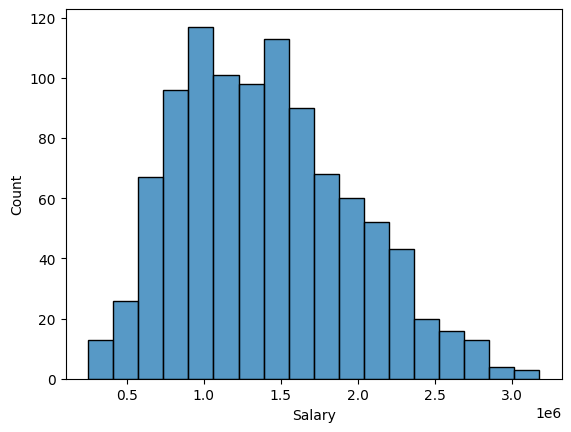

In [107]:
s.histplot(df['Salary'])

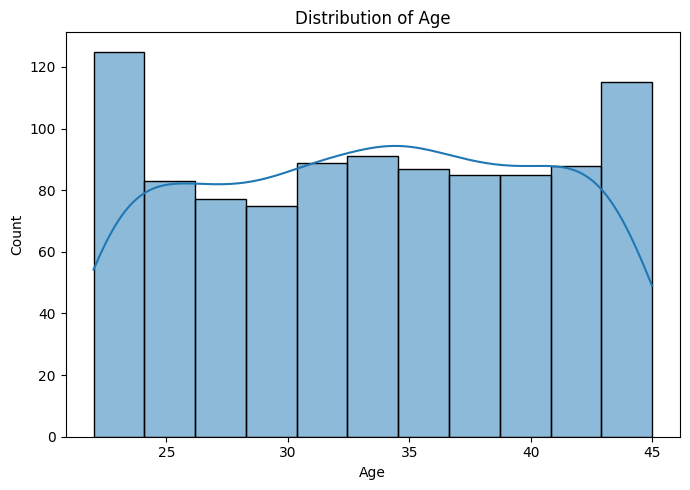

In [108]:
fig,ax =plt.subplots(figsize=(7, 5))
s.histplot(df['Age'], kde=True, ax=ax)
ax.set_title('Distribution of Age')
plt.tight_layout()
plt.show()

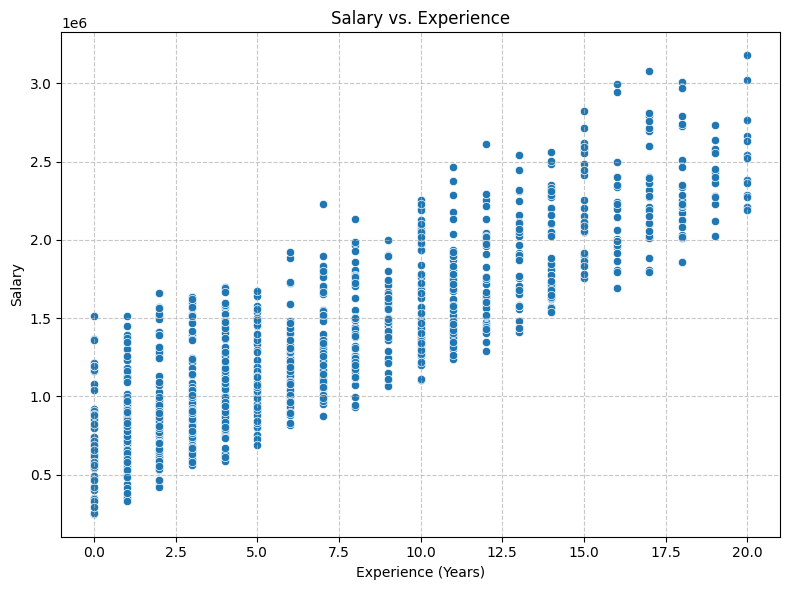

In [109]:
fig,ax= plt.subplots(figsize=(8, 6))
s.scatterplot(x='Experience', y='Salary', data=df,ax=ax)
ax.set_title('Salary vs. Experience')
ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Salary')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: >

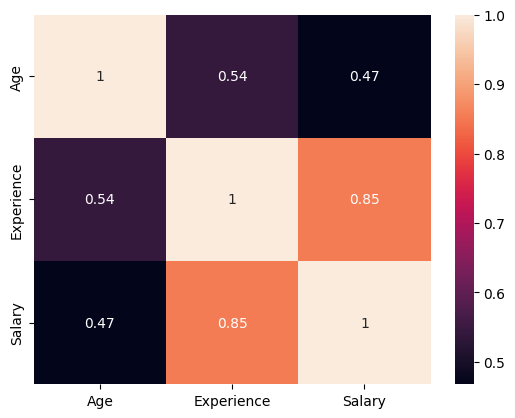

In [110]:
s.heatmap(df.corr(numeric_only=True), annot=True)

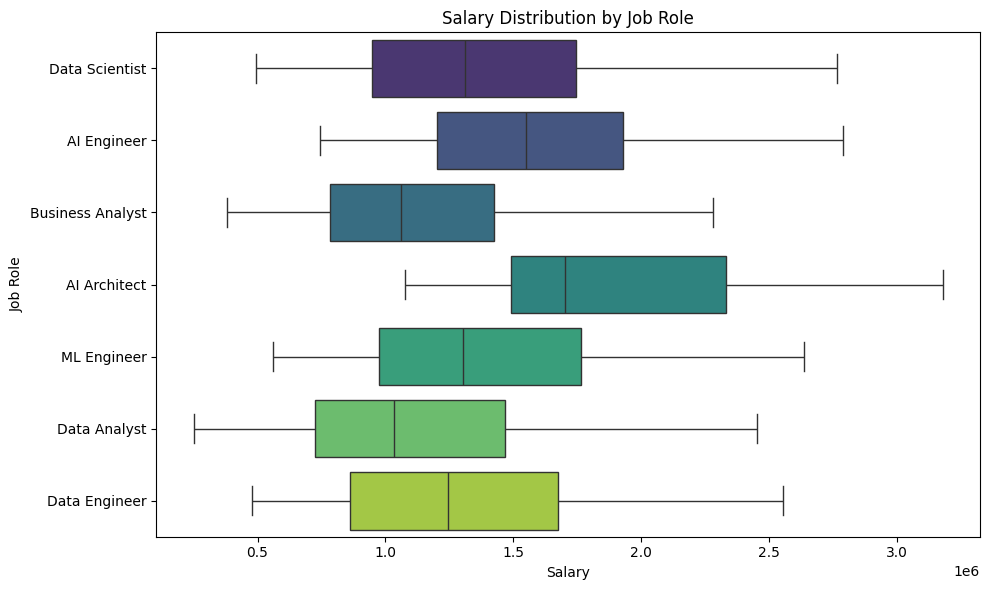

In [119]:
df_plot = pd.read_csv("salary_data.csv")

fig, ax= plt.subplots(figsize=(10, 6))
s.boxplot(x='Salary', y='Job_Role', data=df_plot, ax=ax, palette='viridis', hue='Job_Role', legend=False)
ax.set_title('Salary Distribution by Job Role')
ax.set_xlabel('Salary')
ax.set_ylabel('Job Role')
plt.tight_layout()
plt.show()

In [112]:
#Encoding and model training

e,r,c=LabelEncoder(),LabelEncoder(),LabelEncoder()
df['Education']=e.fit_transform(df['Education'])
df['Job_Role']=r.fit_transform(df['Job_Role'])
df['City']=c.fit_transform(df['City'])
X=df.drop('Salary',axis=1)
y=df['Salary']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

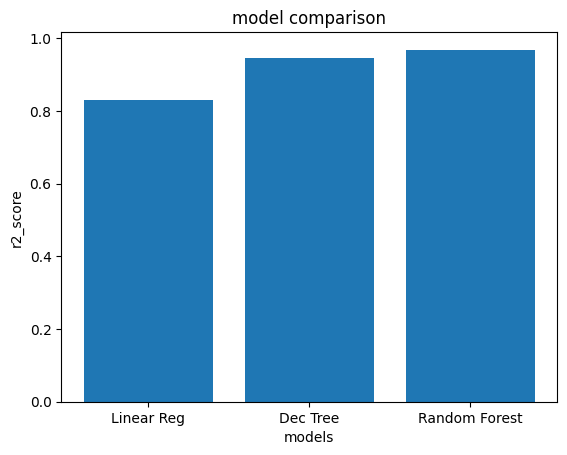

In [113]:
#Fitting models and testing them on 20% of the data. Comparing r2 scores

linear_model=LinearRegression()
linear_model.fit(X_train,y_train)
y_pred_lin= linear_model.predict(X_test)

tree_model= DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train,y_train)
y_pred_tree= tree_model.predict(X_test)

rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf=rf_model.predict(X_test)

models= ['Linear Reg','Dec Tree', 'Random Forest']
accs= [r2_score(y_test,y_pred_lin), r2_score(y_test,y_pred_tree), r2_score(y_test,y_pred_rf)]

plt.bar(models,accs)
plt.title('model comparison')
plt.xlabel('models')
plt.ylabel('r2_score')
plt.show()

In [114]:
# Gradio frontend and salary prediction

model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

import gradio as gr
def predict(age,experience,education,job_role,city):
    x=[[age,experience,
        e.transform([education])[0],
        r.transform([job_role])[0],
        c.transform([city])[0]]]
    p=model.predict(x)[0]
    return f'Predicted Salary: ₹{p:,.0f}'

gr.Interface(
predict,
[
gr.Number(label='Age'),
gr.Number(label='Experience'),
gr.Dropdown(list(e.classes_),label='Education'),
gr.Dropdown(list(r.classes_),label='Job Role'),
gr.Dropdown(list(c.classes_),label='City')
],
gr.Textbox(label='Predicted Salary'),
title='Employee Salary Prediction'
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cdb85e949a397b1542.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [115]:
# Model Comparison

print('Linear Regression')
print('MSE:', mean_squared_error(y_test, y_pred_lin))
print('MAE:', mean_absolute_error(y_test, y_pred_lin))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print('R2:', r2_score(y_test, y_pred_lin))
print("*"*40)
print('Decision Tree')
print('MSE:', mean_squared_error(y_test, y_pred_tree))
print('MAE:', mean_absolute_error(y_test, y_pred_tree))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print('R2:', r2_score(y_test, y_pred_tree))
print("*"*40)
print('Random Forest')
print('MSE:', mean_squared_error(y_test, y_pred_rf))
print('MAE:', mean_absolute_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print('R2:', r2_score(y_test, y_pred_rf))
print("*"*40)


Linear Regression
MSE: 61634360767.88212
MAE: 211742.77122498714
RMSE: 248262.6850090084
R2: 0.8308413832425301
****************************************
Decision Tree
MSE: 19567233803.80681
MAE: 109765.65083333332
RMSE: 139882.92892203399
R2: 0.9462967383325763
****************************************
Random Forest
MSE: 11342781527.981985
MAE: 88977.5941831746
RMSE: 106502.49540730013
R2: 0.9688691630845068
****************************************


# **Importance of each feature for the models**

In [116]:
rfi=pd.DataFrame({"Feature":X.columns,"Importance":rf_model.feature_importances_}).sort_values(by="Importance",ascending=False)
display(rfi)

,Feature,Importance
1,Experience,0.741131
3,Job_Role,0.206942
2,Education,0.032858
4,City,0.009617
0,Age,0.009451


In [117]:
lri=pd.DataFrame({"Feature":X.columns,"Importance":linear_model.coef_}).sort_values(by="Importance",ascending=False)
display(lri)

,Feature,Importance
2,Education,161937.458936
1,Experience,87569.722750
0,Age,919.437140
4,City,-3445.060375
3,Job_Role,-58397.900956


In [118]:
dti=pd.DataFrame({"Feature":X.columns,"Importance":tree_model.feature_importances_}).sort_values(by="Importance",ascending=False)
display(dti)

,Feature,Importance
1,Experience,0.739153
3,Job_Role,0.211796
2,Education,0.035943
4,City,0.007399
0,Age,0.005709
